# Anzahl der Publikationen an niedersächsischen Hochschulen

Frage: Wie hoch ist das Publikationsvolumen je Hochschule in Niedersachsen?

In [225]:
from google.cloud import bigquery
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [226]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [269]:
client = bigquery.Client(project='subugoe-collaborative')

## Liste aller öffentlichen Hochschulen in Niedersachsen

In [3]:
liste_aller_hochschulen = client.query(f"""
                                        SELECT DISTINCT inst_name, dfg_inst_id, ror, sector, federal_state
                                        FROM `subugoe-collaborative.resources.inst_with_federal_state` AS f
                                        JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb
                                            ON CASE
                                                WHEN kb.inst_id = 621 THEN 'https://ror.org/03m2kj587'
                                                ELSE kb.ror 
                                            END = CONCAT('https://ror.org/', f.ror_id)
                                        LEFT JOIN UNNEST(current_sectors) AS sector
                                        WHERE federal_state = 'Niedersachsen' 
                                          AND sector IN ('uni', 'fh', 'khmh') 
                                          AND dfg_inst_id NOT IN (
                                            220269952, -- Fachhochschule für die Wirtschaft Hannover (FHDW)
                                            13033, -- PFH Private Hochschule Göttingen
                                            233118106, -- Leibniz-Fachhochschule
                                            198800578, -- Hochschule 21 Buxtehude
                                            195374963 -- Hochschule Weserbergland
                                          )
                                       """).to_dataframe()

In [65]:
liste_aller_hochschulen.loc[len(liste_aller_hochschulen)] = ['Norddeutsche Hochschule für Rechtspflege', '', 'https://ror.org/02743t710', 'fh', 'Niedersachsen']
liste_aller_hochschulen.replace(
    {'Hochschule für angewandte Wissenschaft und Kunst Hildesheim/Holzminden/Göttingen': 'HAWK Hochschule für angewandte Wissenschaft und Kunst'},
    inplace=True)

In [66]:
liste_aller_hochschulen

,inst_name,dfg_inst_id,ror,sector,federal_state
0,Leuphana Universität Lüneburg,10232,https://ror.org/02w2y2t16,uni,Niedersachsen
1,Carl von Ossietzky Universität Oldenburg,10233,https://ror.org/033n9gh91,uni,Niedersachsen
2,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,10533,https://ror.org/02vvvm705,fh,Niedersachsen
3,Hochschule Emden/Leer,980710,https://ror.org/01bc76c69,fh,Niedersachsen
4,Gottfried Wilhelm Leibniz Universität Hannover,10238,https://ror.org/0304hq317,uni,Niedersachsen
5,"Hochschule für Musik, Theater und Medien Hannover",10246,https://ror.org/00x67m532,khmh,Niedersachsen
6,Hochschule Hannover,10252,https://ror.org/03z6vda50,fh,Niedersachsen
7,Stiftung Tierärztliche Hochschule Hannover,10249,https://ror.org/015qjqf64,uni,Niedersachsen
8,Medizinische Hochschule Hannover (MHH),10247,https://ror.org/00f2yqf98,uni,Niedersachsen
9,HAWK Hochschule für angewandte Wissenschaft un...,10253,https://ror.org/00f5q5839,fh,Niedersachsen


## Nur OpenAlex

In [14]:
oal = client.query(f"""
                    SELECT 
                        CASE 
                            WHEN inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen'
                            WHEN inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            WHEN inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                            ELSE ''
                        END AS inst_name,
                        COUNT(DISTINCT(doi)) AS n
                    FROM `subugoe-collaborative.openalex_walden.works` AS oal, UNNEST(authorships) AS aut, UNNEST(aut.institutions) AS inst
                    WHERE oal.type IN ('article', 'review') 
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111', -- Universität Vechta
                            'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                        )
                    GROUP BY inst_name
                    ORDER BY n DESC
                    """).to_dataframe()

In [15]:
oal

,inst_name,n
0,Georg-August-Universität Göttingen,17851
1,Medizinische Hochschule Hannover (MHH),15177
2,Gottfried Wilhelm Leibniz Universität Hannover,11662
3,Technische Universität Braunschweig,8608
4,Carl von Ossietzky Universität Oldenburg,6393
5,Universitätsmedizin Göttingen,6386
6,Universität Osnabrück,3350
7,Stiftung Tierärztliche Hochschule Hannover,2866
8,Leuphana Universität Lüneburg,2636
9,Technische Universität Clausthal,2148


## OpenAlex mit KB-Kodierung

In [16]:
kb = client.query(f"""
                    SELECT 
                        CASE 
                            WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN kb_inst.inst_id = 621 THEN 'Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            WHEN kb_inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                            ELSE ''
                        END AS inst_name,
                        COUNT(DISTINCT(oal.doi)) AS n
                    FROM `subugoe-collaborative.openbib.kb_a_addr_inst` AS inst
                    JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb_inst
                      ON inst.inst_id_top = kb_inst.inst_id
                    JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                        ON inst.openalex_id = oal.id
                    WHERE oal.type IN ('article', 'review') 
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND (kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111', -- Universität Vechta
                            'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                        ) OR kb_inst.inst_id = 621)
                    GROUP BY inst_name
                    ORDER BY n DESC
                    """).to_dataframe()

In [17]:
kb

,inst_name,n
0,Georg-August-Universität Göttingen,19702
1,Medizinische Hochschule Hannover (MHH),14541
2,Gottfried Wilhelm Leibniz Universität Hannover,11296
3,Technische Universität Braunschweig,8023
4,Carl von Ossietzky Universität Oldenburg,5833
5,Universität Osnabrück,3042
6,Stiftung Tierärztliche Hochschule Hannover,2312
7,Leuphana Universität Lüneburg,2151
8,Technische Universität Clausthal,2028
9,Stiftung Universität Hildesheim,930


## Scopus mit KB-Kodierung

In [242]:
import psycopg2 as pg
import os
from sqlalchemy import create_engine

In [245]:
host = os.environ['KB_HOST']
database = os.environ['KB_DATABASE']
user = os.environ['KB_USER']
pw = os.environ['KB_PASSWORD']
port = os.environ['KB_PORT']
engine = create_engine(f'postgresql://{user}:{pw}@{host}:{port}/{database}')

In [246]:
scp = pd.read_sql("""
                  SELECT 
                      CASE 
                        WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen'
                        WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                        WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                        WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                        WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                        WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                        WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                        WHEN kb_inst.inst_id = 621 THEN 'Hochschule Hannover'
                        WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                        WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                        WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                        WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                        WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                        WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                        WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                        WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                        WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                        WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                        WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                        WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                        WHEN kb_inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                        ELSE ''
                        END AS inst_name,
                        COUNT(DISTINCT(doi)) AS n
                    FROM scp_b_202510.items AS scp
                    JOIN scp_b_202510.add_institution_kb_a AS kb_a
                        ON scp.item_id = kb_a.item_id
                    JOIN scp_b_202510.add_institution_lookup_kb_suppl AS kb_inst
                        ON kb_a.inst_id_top = kb_inst.inst_id
                    WHERE item_type && ARRAY['Review', 'Article']
                        AND pubyear BETWEEN 2020 AND 2024 
                        AND (kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111', -- Universität Vechta
                            'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                        ) OR kb_inst.inst_id = 621)
                    GROUP BY inst_name
                    ORDER BY n DESC
                  """, 
                  con=engine)

In [247]:
scp

,inst_name,n
0,Georg-August-Universität Göttingen,19448
1,Medizinische Hochschule Hannover (MHH),11615
2,Gottfried Wilhelm Leibniz Universität Hannover,8851
3,Technische Universität Braunschweig,6532
4,Carl von Ossietzky Universität Oldenburg,5333
5,Stiftung Tierärztliche Hochschule Hannover,2518
6,Universität Osnabrück,2424
7,Leuphana Universität Lüneburg,1954
8,Technische Universität Clausthal,1616
9,Stiftung Universität Hildesheim,623


## Vergleich zwischen OpenAlex, OpenAlex(KB) und Scopus

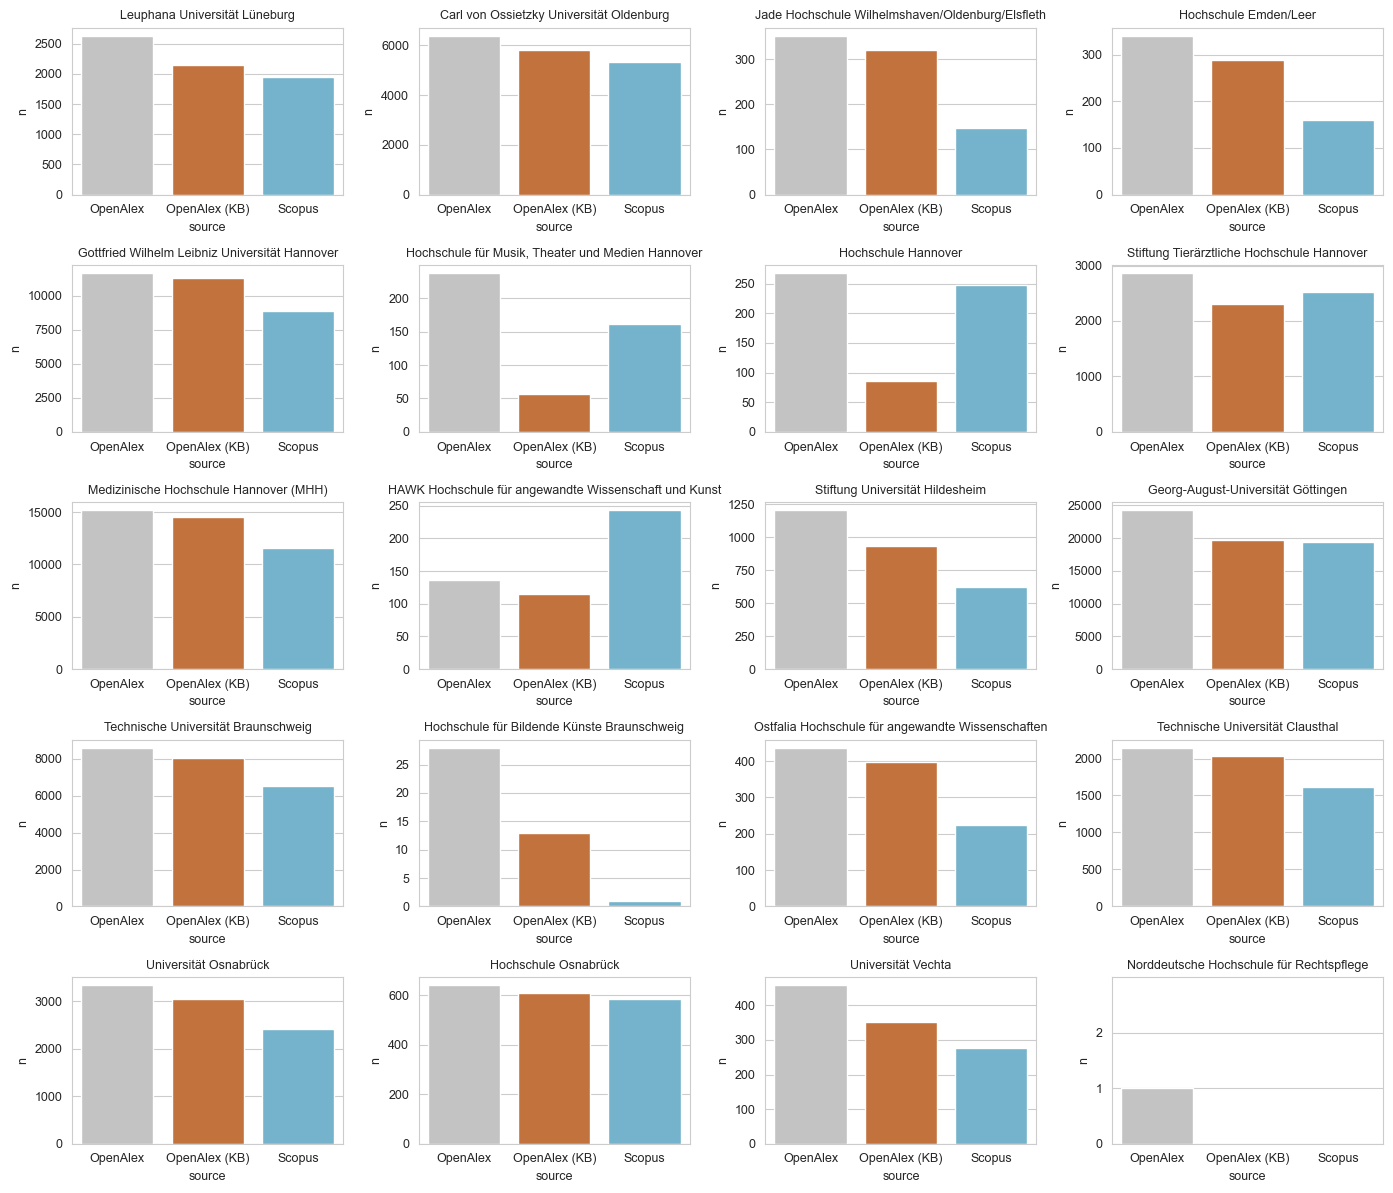

In [268]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    inst_name = liste_aller_hochschulen.iloc[i].inst_name

    oal_inst = oal[oal.inst_name == inst_name]
    kb_inst = kb[kb.inst_name == inst_name]
    scp_inst = scp[scp.inst_name == inst_name]

    oal_value = oal_inst.n.item()

    try:
        kb_value = kb_inst.n.item()
    except:
        kb_value = 0

    try:
        scp_value = scp_inst.n.item()
    except:
        scp_value = 0

    if inst_name == 'Georg-August-Universität Göttingen':
        oal_value += oal[oal.inst_name == 'Universitätsmedizin Göttingen'].n.item()

    
    data = {
            'source': ['OpenAlex', 'OpenAlex (KB)', 'Scopus'],
            'n': [oal_value, kb_value, scp_value]
        }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='source', 
                y='n', 
                hue='source',
                palette=['#c3c3c3', '#D86F27', '#65BADA'],
                ax=ax).set_title(inst_name, fontdict=dict(fontsize=9, fontweight=500))

    if inst_name == 'Norddeutsche Hochschule für Rechtspflege':
        ax.set_ylim(0,3)
        ax.set_yticks(range(0,3))

plt.tight_layout()

plt.show()

## Unterschied zwischen OpenAlex und KB-Kodierung

In [105]:
oal_kb = client.query(f"""
                    SELECT DISTINCT
                      kb.id AS kb_id, 
                      oal.id AS oal_id, 
                      kb.inst_name AS kb_name,
                      oal.inst_name AS oal_name,
                      kb.source AS kb_source, 
                      oal.source AS oal_source
                    FROM (
                      SELECT DISTINCT
                      CASE 
                            WHEN inst.ror = 'https://ror.org/021ft0n22' THEN 'Georg-August-Universität Göttingen' -- UMG in GAU integrieren für Vergleichbarkeit
                            WHEN inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            WHEN inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                            ELSE ''
                        END AS inst_name,
                        oal.id,
                        doi,
                        'OAL' AS source
                      FROM `subugoe-collaborative.openalex_walden.works` AS oal, UNNEST(authorships) AS aut, UNNEST(aut.institutions) AS inst
                      WHERE oal.type IN ('article', 'review') 
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111', -- Universität Vechta
                            'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                        )
                    ) AS oal
                    FULL OUTER JOIN (
                      SELECT 
                          DISTINCT
                          CASE 
                              WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen'
                              WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                              WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                              WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                              WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                              WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                              WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                              WHEN kb_inst.inst_id = 621 THEN 'Hochschule Hannover'
                              WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                              WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                              WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                              WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                              WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                              WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                              WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                              WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                              WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                              WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                              WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                              WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                              WHEN kb_inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                              ELSE ''
                          END AS inst_name,
                          oal.id,
                          oal.doi,
                          'KB' AS source
                      FROM `subugoe-collaborative.openbib.kb_a_addr_inst` AS inst
                      JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb_inst
                        ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON inst.openalex_id = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2024
                          AND (kb_inst.ror IN (
                              'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                              'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                              'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                              'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                              'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                              'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                              'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                              'https://ror.org/03m2kj587', -- Hochschule Hannover
                              'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                              'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                              'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                              'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                              'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                              'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                              'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                              'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                              'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                              'https://ror.org/04qmmjx98', -- Universität Osnabrück
                              'https://ror.org/059vymd37', -- Hochschule Osnabrück
                              'https://ror.org/045y6d111', -- Universität Vechta
                              'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                          ) OR kb_inst.inst_id = 621)
                    ) AS kb
                    ON oal.id = kb.id AND oal.inst_name = kb.inst_name
                    """).to_dataframe()

In [106]:
oal_kb.head()

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source
0,https://openalex.org/W4285202910,https://openalex.org/W4285202910,Universität Vechta,Universität Vechta,KB,OAL
1,https://openalex.org/W3122984040,https://openalex.org/W3122984040,Ostfalia Hochschule für angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaften,KB,OAL
2,https://openalex.org/W4390114573,https://openalex.org/W4390114573,Ostfalia Hochschule für angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaften,KB,OAL
3,https://openalex.org/W4382335657,https://openalex.org/W4382335657,Ostfalia Hochschule für angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaften,KB,OAL
4,https://openalex.org/W4405357091,https://openalex.org/W4405357091,HAWK Hochschule für angewandte Wissenschaft un...,HAWK Hochschule für angewandte Wissenschaft un...,KB,OAL


In [107]:
oal_kb.count()

kb_id         72721
oal_id        79379
kb_name       72721
oal_name      79379
kb_source     72721
oal_source    79379
dtype: int64

In [108]:
oal_kb[(~oal_kb.kb_source.isnull()) & (~oal_kb.oal_source.isnull())].count()

kb_id         69477
oal_id        69477
kb_name       69477
oal_name      69477
kb_source     69477
oal_source    69477
dtype: int64

In [109]:
oal_kb[(oal_kb.kb_source.isnull()) & (~oal_kb.oal_source.isnull())].count()

kb_id            0
oal_id        9902
kb_name          0
oal_name      9902
kb_source        0
oal_source    9902
dtype: int64

In [110]:
oal_kb[(~oal_kb.kb_source.isnull()) & (oal_kb.oal_source.isnull())].count()

kb_id         3244
oal_id           0
kb_name       3244
oal_name         0
kb_source     3244
oal_source       0
dtype: int64

In [111]:
oal_kb[(oal_kb.kb_source.isnull()) & (~oal_kb.oal_source.isnull())].groupby(['oal_name'])['oal_id'].count()

oal_name
Carl von Ossietzky Universität Oldenburg                  911
Georg-August-Universität Göttingen                       3188
Gottfried Wilhelm Leibniz Universität Hannover            934
HAWK Hochschule für angewandte Wissenschaft und Kunst      69
Hochschule Emden/Leer                                      62
Hochschule Hannover                                       187
Hochschule Osnabrück                                      173
Hochschule für Bildende Künste Braunschweig                24
Hochschule für Musik, Theater und Medien Hannover         182
Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth           33
Leuphana Universität Lüneburg                             506
Medizinische Hochschule Hannover (MHH)                    918
Norddeutsche Hochschule für Rechtspflege                    1
Ostfalia Hochschule für angewandte Wissenschaften          46
Stiftung Tierärztliche Hochschule Hannover                580
Stiftung Universität Hildesheim                           288

In [112]:
oal_kb[(~oal_kb.kb_source.isnull()) & (oal_kb.oal_source.isnull())].groupby(['kb_name'])['kb_id'].count()

kb_name
Carl von Ossietzky Universität Oldenburg                  365
Georg-August-Universität Göttingen                       1153
Gottfried Wilhelm Leibniz Universität Hannover            567
HAWK Hochschule für angewandte Wissenschaft und Kunst      48
Hochschule Emden/Leer                                       9
Hochschule Hannover                                         2
Hochschule Osnabrück                                      138
Hochschule für Bildende Künste Braunschweig                 9
Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth            1
Leuphana Universität Lüneburg                              11
Medizinische Hochschule Hannover (MHH)                    262
Ostfalia Hochschule für angewandte Wissenschaften           5
Stiftung Tierärztliche Hochschule Hannover                 13
Stiftung Universität Hildesheim                             8
Technische Universität Braunschweig                       524
Technische Universität Clausthal                           27


In [113]:
oal_kb.groupby(['kb_source', 'oal_source', 'kb_name', 'oal_name'], dropna=False).count().reset_index()

,kb_source,oal_source,kb_name,oal_name,kb_id,oal_id
0,KB,OAL,Carl von Ossietzky Universität Oldenburg,Carl von Ossietzky Universität Oldenburg,5541,5541
1,KB,OAL,Georg-August-Universität Göttingen,Georg-August-Universität Göttingen,18724,18724
2,KB,OAL,Gottfried Wilhelm Leibniz Universität Hannover,Gottfried Wilhelm Leibniz Universität Hannover,10831,10831
3,KB,OAL,HAWK Hochschule für angewandte Wissenschaft un...,HAWK Hochschule für angewandte Wissenschaft un...,67,67
4,KB,OAL,Hochschule Emden/Leer,Hochschule Emden/Leer,283,283
5,KB,OAL,Hochschule Hannover,Hochschule Hannover,85,85
6,KB,OAL,Hochschule Osnabrück,Hochschule Osnabrück,477,477
7,KB,OAL,Hochschule für Bildende Künste Braunschweig,Hochschule für Bildende Künste Braunschweig,4,4
8,KB,OAL,"Hochschule für Musik, Theater und Medien Hannover","Hochschule für Musik, Theater und Medien Hannover",57,57
9,KB,OAL,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,322,322


In [151]:
diff = oal_kb.groupby(['kb_source', 'oal_source', 'kb_name', 'oal_name'], dropna=False).count().reset_index()

In [119]:
oal_kb[oal_kb.oal_id == 'https://openalex.org/W3114667184']

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source
3828,None,https://openalex.org/W3114667184,None,Medizinische Hochschule Hannover (MHH),None,OAL


In [120]:
oal_kb[oal_kb.kb_id == 'https://openalex.org/W3114667184']

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source
1507,https://openalex.org/W3114667184,None,Hochschule Hannover,None,KB,None


In [122]:
oal_kb[oal_kb.oal_id == 'https://openalex.org/W4400555163']

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source


In [121]:
oal_kb[oal_kb.kb_id == 'https://openalex.org/W4400555163']

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source
1004,https://openalex.org/W4400555163,None,Hochschule Hannover,None,KB,None


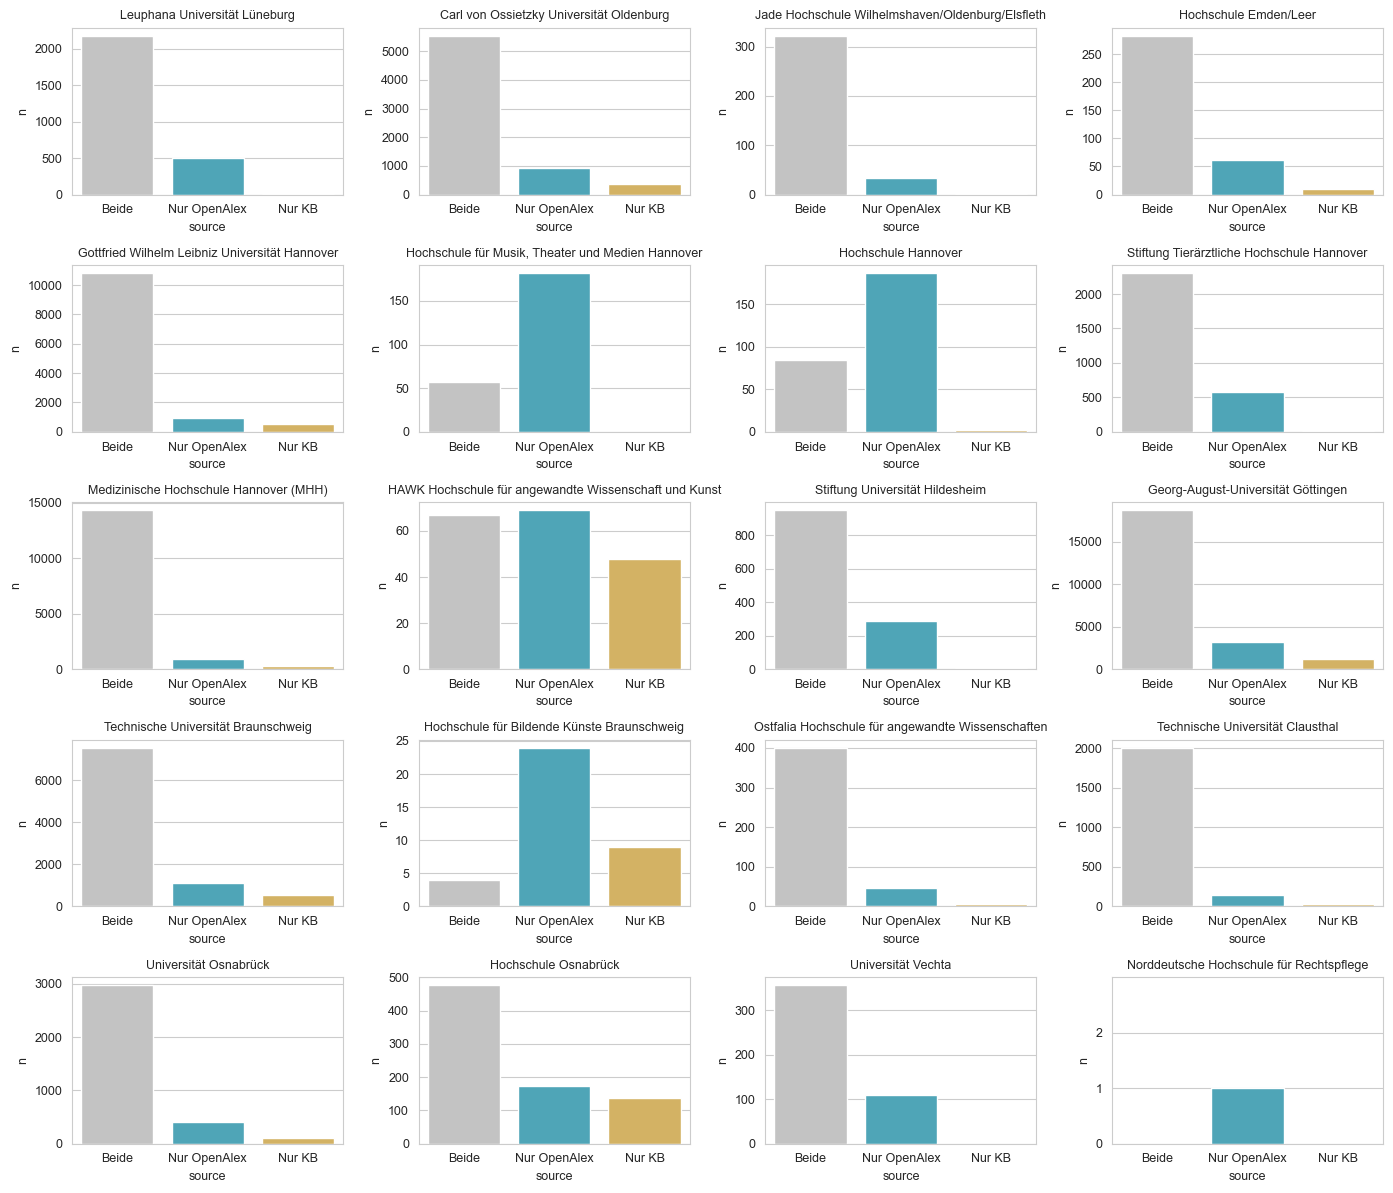

In [248]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    inst_name = liste_aller_hochschulen.iloc[i].inst_name

    df = diff[(diff.oal_name == inst_name) | (diff.kb_name == inst_name)]

    try:
        both = df[(~df.kb_source.isnull()) & (~df.oal_source.isnull())]['kb_id'].item()
    except:
        both = 0

    try:
        only_kb = df[(~df.kb_source.isnull()) & (df.oal_source.isnull())]['kb_id'].item()
    except:
        only_kb = 0

    try:
        only_oal = df[(df.kb_source.isnull()) & (~df.oal_source.isnull())]['oal_id'].item()
    except:
        only_oal = 0

    
    data = {
            'source': ['Beide', 'Nur OpenAlex', 'Nur KB'],
            'n': [both, only_oal, only_kb]
        }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='source', 
                y='n', 
                hue='source',
                palette=['#c3c3c3', '#3EB1C8', '#E5BA52'],
                ax=ax).set_title(inst_name, fontdict=dict(fontsize=9, fontweight=500))

    if inst_name == 'Norddeutsche Hochschule für Rechtspflege':
        ax.set_ylim(0,3)
        ax.set_yticks(range(0,3))

plt.tight_layout()

plt.show()